# 03. Power, MDE, Sample Size, and Practical Significance

The previous notebooks explained how randomized experiments identify causal effects. This notebook is about whether an experiment is informative enough to support a decision.

A randomized experiment can be perfectly implemented and still be too small to answer the business question. If the treatment effect is smaller than what the experiment can reliably detect, the readout may look inconclusive even when the treatment has real value. Conversely, a huge experiment can detect a tiny effect that is statistically significant but not worth shipping.

This lecture focuses on four planning concepts:

1. **Power**: the probability that the experiment detects an effect of a specified size.
2. **Minimum detectable effect (MDE)**: the effect size an experiment can detect with a target power.
3. **Sample size**: the number of units needed to detect a decision-relevant effect.
4. **Practical significance**: whether the effect is large enough to matter for the product, business, policy, or scientific question.

The core idea is:

> A good experiment is designed around the smallest effect that would change the decision.

Power analysis has a long statistical history (Cohen, 1992). In product experimentation, the same logic becomes a planning tool for deciding whether an experiment is feasible, how long it should run, and whether the result will be actionable (Kohavi et al., 2008; Athey & Imbens, 2017).

## Learning Goals

By the end of this notebook, you should be able to:

- Explain power, type I error, type II error, and MDE in experiment language.
- Compute MDE for a continuous outcome in a two-arm experiment.
- Compute approximate sample size for a target effect size and target power.
- Understand how variance, allocation ratio, baseline conversion rate, and traffic affect power.
- Distinguish statistical significance from practical significance.
- Use simulation to validate power calculations.
- Explain why underpowered studies produce noisy and exaggerated significant estimates.
- Quantify how variance reduction methods such as CUPED affect MDE and required sample size.
- Build a planning table for an industry experiment.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "planning": "#d7ecff",
    "decision": "#eadcf8",
    "metric": "#ffd6db",
    "guardrail": "#ffe0c2",
    "neutral": "#f7f7f7",
    "warning": "#fff1c7",
}

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.65")
    dot.attr("node", shape="box", style="rounded,filled", color="#2b2b2b", fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            attrs = {}
        else:
            src, dst, attrs = edge
        dot.edge(src, dst, **attrs)
    return dot


def z_alpha_two_sided(alpha=0.05):
    """Convert a two-sided alpha level into the normal critical value.

    Args:
        alpha: Type-I error level used for testing or intervals.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    return stats.norm.ppf(1 - alpha / 2)


def z_power(power=0.80):
    """Convert a target power level into the corresponding normal quantile.

    Args:
        power: Target probability of detecting the specified effect.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    return stats.norm.ppf(power)


def se_difference_means(sigma, n_total, treatment_fraction=0.5):
    """Compute the standard error for a two-arm continuous-outcome experiment.

    Args:
        sigma: Outcome standard deviation used in continuous-outcome power formulas.
        n_total: Total planned sample size across treatment arms.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    n_t = n_total * treatment_fraction
    n_c = n_total * (1 - treatment_fraction)
    return sigma * np.sqrt(1 / n_t + 1 / n_c)


def mde_continuous(sigma, n_total, alpha=0.05, power=0.80, treatment_fraction=0.5):
    """Compute the minimum detectable effect for a continuous outcome.

    Args:
        sigma: Outcome standard deviation used in continuous-outcome power formulas.
        n_total: Total planned sample size across treatment arms.
        alpha: Type-I error level used for testing or intervals.
        power: Target probability of detecting the specified effect.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    multiplier = z_alpha_two_sided(alpha) + z_power(power)
    return multiplier * se_difference_means(sigma, n_total, treatment_fraction)


def sample_size_continuous(sigma, effect, alpha=0.05, power=0.80, treatment_fraction=0.5):
    """Compute required sample size for a continuous-outcome experiment.

    Args:
        sigma: Outcome standard deviation used in continuous-outcome power formulas.
        effect: Treatment effect size used in power or simulation calculations.
        alpha: Type-I error level used for testing or intervals.
        power: Target probability of detecting the specified effect.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    multiplier = z_alpha_two_sided(alpha) + z_power(power)
    allocation_term = 1 / treatment_fraction + 1 / (1 - treatment_fraction)
    n_total = (sigma * multiplier / effect) ** 2 * allocation_term
    return int(np.ceil(n_total))


def analytical_power_continuous(effect, sigma, n_total, alpha=0.05, treatment_fraction=0.5):
    """Compute analytical power for a continuous-outcome A/B test.

    Args:
        effect: Treatment effect size used in power or simulation calculations.
        sigma: Outcome standard deviation used in continuous-outcome power formulas.
        n_total: Total planned sample size across treatment arms.
        alpha: Type-I error level used for testing or intervals.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    se = se_difference_means(sigma, n_total, treatment_fraction)
    zcrit = z_alpha_two_sided(alpha)
    noncentral = effect / se
    # Two-sided test power under a normal approximation.
    return stats.norm.sf(zcrit - noncentral) + stats.norm.cdf(-zcrit - noncentral)


def se_difference_proportions(p0, p1, n_total, treatment_fraction=0.5):
    """Compute the standard error for a two-arm conversion-rate difference.

    Args:
        p0: Baseline conversion probability for the control group.
        p1: Conversion probability for the treatment group.
        n_total: Total planned sample size across treatment arms.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    n_t = n_total * treatment_fraction
    n_c = n_total * (1 - treatment_fraction)
    return np.sqrt(p1 * (1 - p1) / n_t + p0 * (1 - p0) / n_c)


def analytical_power_proportion(p0, lift_abs, n_total, alpha=0.05, treatment_fraction=0.5):
    """Compute analytical power for an absolute conversion-rate lift.

    Args:
        p0: Baseline conversion probability for the control group.
        lift_abs: Absolute conversion-rate lift being evaluated.
        n_total: Total planned sample size across treatment arms.
        alpha: Type-I error level used for testing or intervals.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    p1 = np.clip(p0 + lift_abs, 0, 1)
    se = se_difference_proportions(p0, p1, n_total, treatment_fraction)
    zcrit = z_alpha_two_sided(alpha)
    noncentral = lift_abs / se
    return stats.norm.sf(zcrit - noncentral) + stats.norm.cdf(-zcrit - noncentral)

## 1. The Experiment Planning Loop

Power analysis belongs before an experiment starts. It connects the causal question to the operational plan.

A useful planning sequence is:

1. Define the product or policy decision.
2. Choose the primary metric.
3. Define the smallest effect that would change the decision.
4. Estimate baseline variance or baseline conversion rate.
5. Choose type I error rate and desired power.
6. Compute sample size, duration, or MDE.
7. Check feasibility and guardrails.
8. Decide whether to run, redesign, narrow the population, use variance reduction, or abandon the experiment.

If a team skips this step, the experiment may finish with a painfully familiar sentence: "The result is not significant, but maybe we just need more data." Power planning makes that uncertainty visible before the experiment consumes time and traffic.

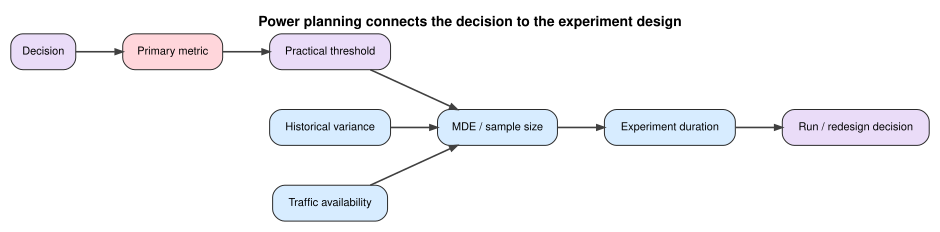

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
planning_edges = [
    ("Decision", "Primary metric"),
    ("Primary metric", "Practical threshold"),
    ("Historical variance", "MDE / sample size"),
    ("Traffic availability", "MDE / sample size"),
    ("Practical threshold", "MDE / sample size"),
    ("MDE / sample size", "Experiment duration"),
    ("Experiment duration", "Run / redesign decision"),
]
planning_colors = {
    "Decision": COLORS["decision"],
    "Primary metric": COLORS["metric"],
    "Practical threshold": COLORS["decision"],
    "Historical variance": COLORS["planning"],
    "Traffic availability": COLORS["planning"],
    "MDE / sample size": COLORS["planning"],
    "Experiment duration": COLORS["planning"],
    "Run / redesign decision": COLORS["decision"],
}

smart_display(make_dag(planning_edges, "Power planning connects the decision to the experiment design", planning_colors))

## 2. Power Vocabulary

Let the null hypothesis be that the treatment effect is zero. Let the true effect be some positive value $\delta$.

| Concept | Meaning | Product interpretation |
|---|---|---|
| $\alpha$ | Type I error rate | False positive rate under no effect |
| $\beta$ | Type II error rate | Probability of missing an effect of size $\delta$ |
| Power | $1 - \beta$ | Probability of detecting an effect of size $\delta$ |
| MDE | Minimum detectable effect | Smallest effect the design can detect with target power |
| Practical threshold | Smallest effect worth acting on | Launch/rollback/iterate threshold |
| Statistical significance | Evidence against null under a test | Does not imply business importance |
| Practical significance | Decision relevance | May require cost, risk, and opportunity calculations |

For a two-sided test at $\alpha = 0.05$ and power $0.80$, the normal-approximation multiplier is:

$$
z_{1-\alpha/2} + z_{power} \approx 1.96 + 0.84 = 2.80.
$$

That multiplier appears repeatedly in MDE and sample-size formulas.

In [4]:
alpha = 0.05
power_target = 0.80
pd.DataFrame({
    "quantity": ["z_(1-alpha/2)", "z_power", "sum multiplier"],
    "value": [z_alpha_two_sided(alpha), z_power(power_target), z_alpha_two_sided(alpha) + z_power(power_target)],
}).round(3)

,quantity,value
0,z_(1-alpha/2),1.960
1,z_power,0.842
2,sum multiplier,2.802


## 3. Continuous Outcome: MDE for a Difference in Means

For a two-arm experiment with a continuous outcome and equal allocation, the standard error of the treatment-control difference is approximately:

$$
SE(\widehat{\tau}) = \sigma\sqrt{\frac{1}{n_T} + \frac{1}{n_C}}.
$$

With equal allocation, $n_T = n_C = N/2$, so:

$$
SE(\widehat{\tau}) = \sigma\sqrt{\frac{4}{N}}.
$$

The minimum detectable effect under a normal approximation is:

$$
MDE = (z_{1-\alpha/2} + z_{power}) \times SE(\widehat{\tau}).
$$

This formula makes the core relationships obvious:

- Larger outcome noise $\sigma$ increases MDE.
- Larger sample size $N$ decreases MDE.
- Higher desired power increases MDE for fixed $N$.
- A stricter significance threshold increases MDE for fixed $N$.

In [5]:
# Assemble the Continuous Outcome: MDE for a Difference in Means summary table used for interpretation.
sigma = 12.0
n_total = 20_000
mde = mde_continuous(sigma=sigma, n_total=n_total, alpha=0.05, power=0.80)

pd.DataFrame({
    "input_or_output": ["Outcome SD", "Total sample size", "Alpha", "Target power", "MDE"],
    "value": [sigma, n_total, 0.05, 0.80, mde],
}).round(3)

,input_or_output,value
0,Outcome SD,12.000
1,Total sample size,20000.000
2,Alpha,0.050
3,Target power,0.800
4,MDE,0.475


If the historical standard deviation of the metric is about 12 units and the experiment can enroll 20,000 users total, the design can detect an effect of roughly the computed MDE with 80% power at a two-sided 5% significance level.

Effects smaller than this can still be estimated, but the experiment will often fail to distinguish them from noise. That is the difference between "estimating an effect" and "having enough information to make a confident decision."

## 4. Sample Size for a Practical Threshold

Often the better planning question is not "What can I detect with available traffic?" but:

> How many users do I need to detect the smallest effect worth acting on?

Solving the MDE formula for total sample size gives:

$$
N = \left(\frac{\sigma(z_{1-\alpha/2} + z_{power})}{\delta}\right)^2
\left(\frac{1}{p} + \frac{1}{1-p}\right),
$$

where $p$ is the treatment allocation fraction and $\delta$ is the practical effect threshold.

For equal allocation, $p = 0.5$, so the allocation term is 4.

In [6]:
# Assemble the Sample Size for a Practical Threshold summary table used for interpretation.
practical_effect = 0.30
required_n = sample_size_continuous(sigma=sigma, effect=practical_effect, alpha=0.05, power=0.80, treatment_fraction=0.5)
traffic_per_day = 4_000
required_days = np.ceil(required_n / traffic_per_day)

pd.DataFrame({
    "planning_input": ["Outcome SD", "Smallest practical effect", "Target power", "Alpha", "Traffic per day", "Required total users", "Approx required days"],
    "value": [sigma, practical_effect, 0.80, 0.05, traffic_per_day, required_n, required_days],
}).round(2)

,planning_input,value
0,Outcome SD,12.00
1,Smallest practical effect,0.30
2,Target power,0.80
3,Alpha,0.05
4,Traffic per day,4000.00
5,Required total users,50233.00
6,Approx required days,13.00


This is where power analysis becomes a business conversation. If the smallest useful effect is 0.30 units and the required duration is too long, the team has options:

- accept lower power;
- target a higher-impact population;
- use a more sensitive metric;
- reduce outcome variance using pre-experiment covariates;
- run a larger traffic allocation;
- decide that the experiment is not worth running.

The wrong move is to run an obviously underpowered experiment and hope the p-value cooperates.

## 5. Power Curves

A power curve shows the probability of detecting different true effect sizes for a fixed experiment design. It is one of the clearest planning visuals because it shows the experiment's sensitivity across a range of possible effects.

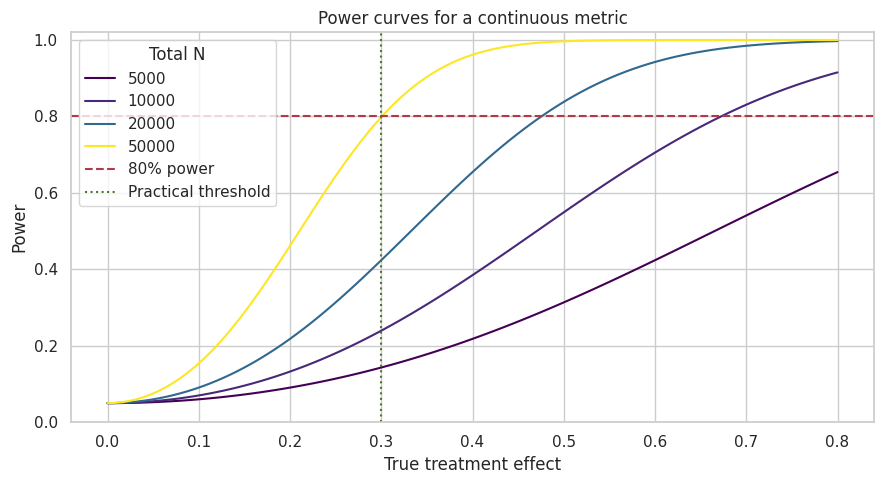

In [7]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
effects = np.linspace(0, 0.80, 101)
sample_sizes = [5_000, 10_000, 20_000, 50_000]

power_rows = []
for n in sample_sizes:
    for effect in effects:
        power_rows.append({
            "n_total": n,
            "effect": effect,
            "power": analytical_power_continuous(effect, sigma=sigma, n_total=n, alpha=0.05),
        })
power_df = pd.DataFrame(power_rows)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=power_df, x="effect", y="power", hue="n_total", palette="viridis", ax=ax)
ax.axhline(0.80, color="#b23a48", linestyle="--", label="80% power")
ax.axvline(practical_effect, color="#4f772d", linestyle=":", label="Practical threshold")
ax.set_title("Power curves for a continuous metric")
ax.set_xlabel("True treatment effect")
ax.set_ylabel("Power")
ax.set_ylim(0, 1.02)
ax.legend(title="Total N")
plt.tight_layout()
plt.show()

The same experiment has low power for small effects and high power for large effects. That is why power must always be attached to a specific effect size.

Saying "the experiment has 80% power" is incomplete. The full sentence is "the experiment has 80% power to detect an effect of size $\delta$ under these assumptions."

## 6. MDE Shrinks Slowly With Sample Size

MDE decreases at the rate $1/\sqrt{N}$. This square-root relationship is sobering. To cut MDE in half, you need about four times as much traffic, holding variance and allocation constant.

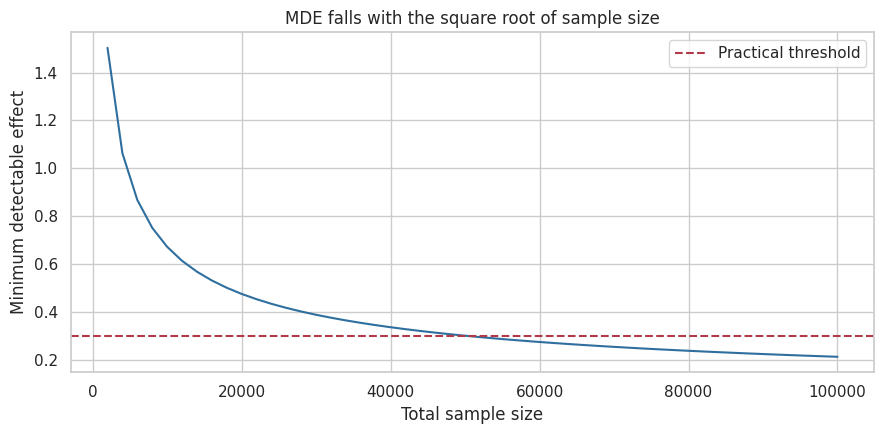

,n_total,mde
0,2000,1.503
4,10000,0.672
9,20000,0.475
24,50000,0.301
49,100000,0.213


In [8]:
# Build the MDE Shrinks Slowly With Sample Size plot from the quantities computed above.
n_grid = np.arange(2_000, 100_001, 2_000)
mde_grid = pd.DataFrame({
    "n_total": n_grid,
    "mde": [mde_continuous(sigma=sigma, n_total=n, alpha=0.05, power=0.80) for n in n_grid],
})

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=mde_grid, x="n_total", y="mde", color="#2f6f9f", ax=ax)
ax.axhline(practical_effect, color="#b23a48", linestyle="--", label="Practical threshold")
ax.set_title("MDE falls with the square root of sample size")
ax.set_xlabel("Total sample size")
ax.set_ylabel("Minimum detectable effect")
ax.legend()
plt.tight_layout()
plt.show()

mde_grid.iloc[[0, 4, 9, 24, 49]].round(3)

The curve falls quickly at first and then flattens. This is why very small improvements can be hard to measure even in large products. Mature products may care about small lifts, but detecting those lifts requires large traffic, low-variance metrics, or variance reduction.

## 7. Binary Metrics: Conversion Rate MDE

For a binary metric such as conversion, click-through, activation, or retention, the variance depends on the baseline rate.

For treatment conversion rate $p_1$ and control conversion rate $p_0$, the standard error is approximately:

$$
SE(\widehat{p}_1 - \widehat{p}_0) = \sqrt{\frac{p_1(1-p_1)}{n_T} + \frac{p_0(1-p_0)}{n_C}}.
$$

Rare metrics can require very large samples because there are few events, even if there are many users.

In [9]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def mde_proportion_search(p0, n_total, alpha=0.05, power=0.80, treatment_fraction=0.5):
    # Search over absolute lifts. This avoids relying on a closed-form approximation that fixes p1=p0.
    """Search for the smallest conversion lift that reaches target power.

    Args:
        p0: Baseline conversion probability for the control group.
        n_total: Total planned sample size across treatment arms.
        alpha: Type-I error level used for testing or intervals.
        power: Target probability of detecting the specified effect.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        float: Numeric diagnostic or estimate used by the lecture.
    """
    grid = np.linspace(0.00001, min(0.50, 1 - p0), 20_000)
    powers = np.array([analytical_power_proportion(p0, lift, n_total, alpha, treatment_fraction) for lift in grid])
    idx = np.searchsorted(powers, power)
    if idx >= len(grid):
        return np.nan
    return grid[idx]

baseline_rates = [0.01, 0.03, 0.10, 0.30, 0.50]
conversion_rows = []
for p0 in baseline_rates:
    abs_mde = mde_proportion_search(p0, n_total=50_000, alpha=0.05, power=0.80)
    conversion_rows.append({
        "baseline_rate": p0,
        "absolute_mde": abs_mde,
        "relative_mde": abs_mde / p0,
        "n_total": 50_000,
    })
conversion_mde_table = pd.DataFrame(conversion_rows)
conversion_mde_table.round(4)

,baseline_rate,absolute_mde,relative_mde,n_total
0,0.01,0.0027,0.2660,50000
1,0.03,0.0044,0.1478,50000
2,0.10,0.0077,0.0766,50000
3,0.30,0.0116,0.0385,50000
4,0.50,0.0125,0.0251,50000


In Binary Metrics: Conversion Rate MDE, the table turns noise into decision precision. If the detectable effect exceeds the business-relevant effect, the experiment is too weak for that decision.

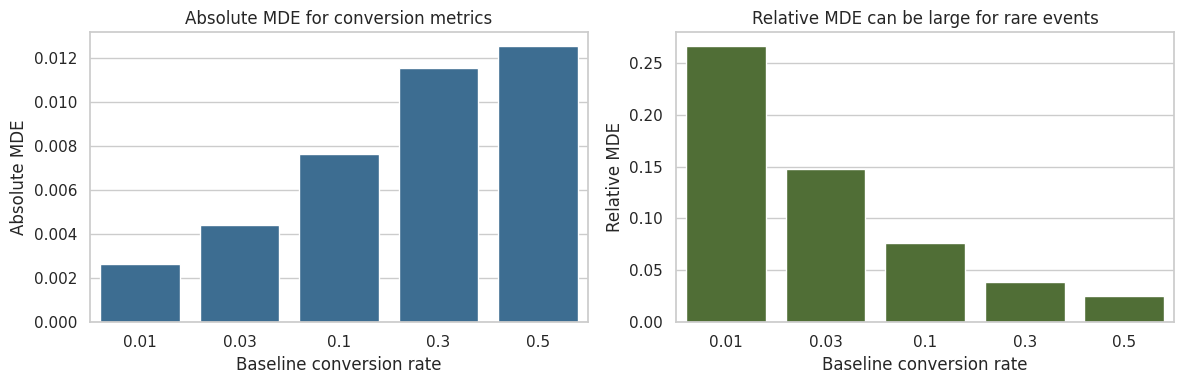

In [10]:
# Build the Binary Metrics: Conversion Rate MDE plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=conversion_mde_table, x="baseline_rate", y="absolute_mde", color="#2f6f9f", ax=axes[0])
axes[0].set_title("Absolute MDE for conversion metrics")
axes[0].set_xlabel("Baseline conversion rate")
axes[0].set_ylabel("Absolute MDE")

sns.barplot(data=conversion_mde_table, x="baseline_rate", y="relative_mde", color="#4f772d", ax=axes[1])
axes[1].set_title("Relative MDE can be large for rare events")
axes[1].set_xlabel("Baseline conversion rate")
axes[1].set_ylabel("Relative MDE")

plt.tight_layout()
plt.show()

A 1% baseline conversion metric may need a large relative lift to be detectable with 50,000 users. A 30% baseline metric can detect smaller relative changes because events are more common.

This is why metric choice matters. A rare downstream metric may be closer to the business objective, but a more frequent leading metric may be more sensitive. The tradeoff is that leading metrics must be validated as meaningful proxies.

## 8. Practical Significance Versus Statistical Significance

Statistical significance asks whether the data are surprising under a null effect. Practical significance asks whether the estimated effect is large enough to justify action.

For a product experiment, a launch decision might depend on:

- incremental revenue or value;
- engineering and maintenance cost;
- guardrail risks;
- user trust or fairness concerns;
- opportunity cost of shipping this instead of another feature;
- whether the effect persists after novelty fades.

A tiny effect can be statistically significant in a huge sample and still be irrelevant. A meaningful effect can be estimated too imprecisely in a small sample.

In [11]:
# Assemble the Practical Significance Versus Statistical Significance summary table used for interpretation.
scenarios = pd.DataFrame({
    "scenario": [
        "Huge experiment, tiny effect",
        "Small experiment, meaningful but noisy effect",
        "Right-sized experiment, actionable effect",
    ],
    "estimate": [0.025, 0.35, 0.32],
    "std_error": [0.008, 0.22, 0.08],
    "practical_threshold": [0.20, 0.20, 0.20],
})
scenarios["ci_lower"] = scenarios["estimate"] - 1.96 * scenarios["std_error"]
scenarios["ci_upper"] = scenarios["estimate"] + 1.96 * scenarios["std_error"]
scenarios["p_value"] = 2 * (1 - stats.norm.cdf(np.abs(scenarios["estimate"] / scenarios["std_error"])))
scenarios["statistically_significant"] = scenarios["p_value"] < 0.05
scenarios["practically_actionable"] = scenarios["ci_lower"] > scenarios["practical_threshold"]
scenarios.round(3)

,scenario,estimate,std_error,practical_threshold,ci_lower,ci_upper,p_value,statistically_significant,practically_actionable
0,"Huge experiment, tiny effect",0.025,0.008,0.2,0.009,0.041,0.002,True,False
1,"Small experiment, meaningful but noisy effect",0.350,0.220,0.2,-0.081,0.781,0.112,False,False
2,"Right-sized experiment, actionable effect",0.320,0.080,0.2,0.163,0.477,0.000,True,False


In Practical Significance Versus Statistical Significance, the table links the statistical evidence to the launch decision. A launch readout needs the primary result, the guardrail risks, and the multiplicity story in the same frame.

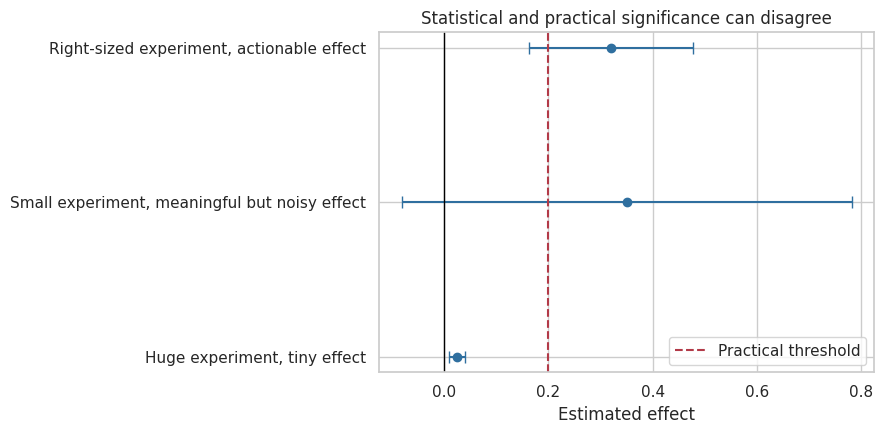

In [12]:
# Build the Practical Significance Versus Statistical Significance plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    scenarios["estimate"],
    scenarios["scenario"],
    xerr=[scenarios["estimate"] - scenarios["ci_lower"], scenarios["ci_upper"] - scenarios["estimate"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.20, color="#b23a48", linestyle="--", label="Practical threshold")
ax.set_title("Statistical and practical significance can disagree")
ax.set_xlabel("Estimated effect")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

The first scenario is statistically significant but too small to justify action. The second scenario has a point estimate above the practical threshold, but the interval is too wide to support a confident decision. The third scenario is both statistically and practically compelling.

For industry work, the best readout is not simply "p < 0.05". It is a decision statement tied to a practical threshold.

## 9. Validating Power With Simulation

Analytical formulas are approximations. Simulation is a useful way to check whether a proposed design behaves as expected under a realistic data-generating process.

We will simulate repeated A/B tests where the true treatment effect is known, then estimate empirical power as the fraction of tests with $p < 0.05$.

**Dataset and experiment setup.** The simulations here are not meant to represent one fixed dataset. They repeatedly generate experiments under known effect sizes, variances, conversion rates, and sample sizes. Each repeated experiment is a possible future A/B test. This makes power tangible: power is the share of future experiments that would detect an effect of a given size under the chosen design. The setup also separates statistical detectability from practical value, which is crucial when a tiny detectable lift may still be too small to justify shipping a product change.

In [13]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_continuous_tests(n_total, effect, sigma, n_sims=2_000, alpha=0.05, seed=123):
    """Simulate repeated continuous-outcome experiments to validate power formulas.

    Args:
        n_total: Total planned sample size across treatment arms.
        effect: Treatment effect size used in power or simulation calculations.
        sigma: Outcome standard deviation used in continuous-outcome power formulas.
        n_sims: Number of Monte Carlo repetitions.
        alpha: Type-I error level used for testing or intervals.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng_local = np.random.default_rng(seed)
    n_t = n_total // 2
    n_c = n_total - n_t
    pvals = np.empty(n_sims)
    estimates = np.empty(n_sims)
    for s in range(n_sims):
        y_c = rng_local.normal(loc=0.0, scale=sigma, size=n_c)
        y_t = rng_local.normal(loc=effect, scale=sigma, size=n_t)
        est = y_t.mean() - y_c.mean()
        se = np.sqrt(y_t.var(ddof=1) / n_t + y_c.var(ddof=1) / n_c)
        z = est / se
        pvals[s] = 2 * (1 - stats.norm.cdf(abs(z)))
        estimates[s] = est
    return pd.DataFrame({"estimate": estimates, "p_value": pvals})

sim_n = sample_size_continuous(sigma=sigma, effect=practical_effect, alpha=0.05, power=0.80)
sim_results = simulate_continuous_tests(n_total=sim_n, effect=practical_effect, sigma=sigma, n_sims=2_000)
empirical_power = (sim_results["p_value"] < 0.05).mean()
formula_power = analytical_power_continuous(practical_effect, sigma=sigma, n_total=sim_n, alpha=0.05)

pd.DataFrame({
    "quantity": ["Planned total N", "Target effect", "Analytical power", "Simulated empirical power", "Mean estimate"],
    "value": [sim_n, practical_effect, formula_power, empirical_power, sim_results["estimate"].mean()],
}).round(4)

,quantity,value
0,Planned total N,50233.0000
1,Target effect,0.3000
2,Analytical power,0.8000
3,Simulated empirical power,0.8160
4,Mean estimate,0.3018


In Validating Power With Simulation, the table turns noise into decision precision. A design that can only detect large effects may still be useless for a smaller practical decision.

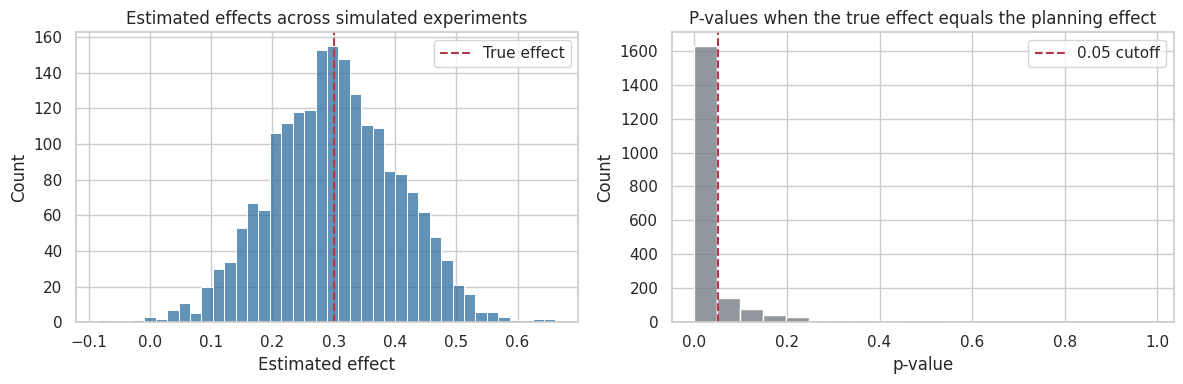

In [14]:
# Build the Validating Power With Simulation plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(sim_results["estimate"], bins=40, color="#2f6f9f", ax=axes[0])
axes[0].axvline(practical_effect, color="#b23a48", linestyle="--", label="True effect")
axes[0].set_title("Estimated effects across simulated experiments")
axes[0].set_xlabel("Estimated effect")
axes[0].legend()

sns.histplot(sim_results["p_value"], bins=20, color="#6c757d", ax=axes[1])
axes[1].axvline(0.05, color="#b23a48", linestyle="--", label="0.05 cutoff")
axes[1].set_title("P-values when the true effect equals the planning effect")
axes[1].set_xlabel("p-value")
axes[1].legend()

plt.tight_layout()
plt.show()

The simulated power is close to the analytical target. In real work, simulation is especially useful when metrics are skewed, clustered, capped, ratio-based, delayed, or affected by missingness. Analytical formulas are a starting point; simulation lets us stress-test more realistic assumptions.

## 10. Underpowered Experiments and Exaggerated Significant Results

Underpowered experiments do not merely produce more non-significant results. When they do produce significant results, those estimates can be exaggerated because only unusually large noisy estimates cross the significance threshold.

Gelman and Carlin (2014) discuss this problem using ideas such as type S errors (wrong sign) and type M errors (magnitude exaggeration). The practical lesson is simple: do not trust a noisy, barely powered experiment merely because it happened to be significant.

In [15]:
# Build the summary table used to connect the calculation back to the design question.
small_n = 2_000
small_effect = 0.20
small_sigma = 12.0
small_power = analytical_power_continuous(small_effect, small_sigma, small_n, alpha=0.05)
underpowered = simulate_continuous_tests(n_total=small_n, effect=small_effect, sigma=small_sigma, n_sims=8_000, seed=456)
underpowered["significant"] = underpowered["p_value"] < 0.05
sig = underpowered.query("significant")

underpowered_summary = pd.DataFrame({
    "quantity": [
        "Analytical power",
        "Empirical significant share",
        "Mean estimate across all simulations",
        "Mean estimate among significant simulations",
        "Magnitude exaggeration among significant simulations",
        "Wrong-sign share among significant simulations",
    ],
    "value": [
        small_power,
        underpowered["significant"].mean(),
        underpowered["estimate"].mean(),
        sig["estimate"].mean(),
        sig["estimate"].mean() / small_effect,
        (np.sign(sig["estimate"]) != np.sign(small_effect)).mean(),
    ],
})
underpowered_summary.round(4)

,quantity,value
0,Analytical power,0.0661
1,Empirical significant share,0.0639
2,Mean estimate across all simulations,0.1998
3,Mean estimate among significant simulations,0.9243
4,Magnitude exaggeration among significant simul...,4.6216
5,Wrong-sign share among significant simulations,0.1429


In Underpowered Experiments and Exaggerated Significant Results, the table turns noise into decision precision. Power planning asks whether the experiment can see the effect that would actually change the decision.

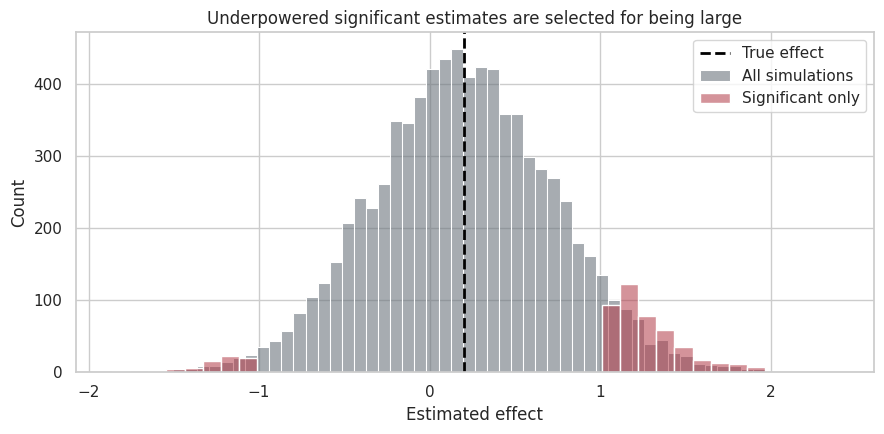

In [16]:
# Build the Underpowered Experiments and Exaggerated Significant Results plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(underpowered["estimate"], bins=60, color="#6c757d", alpha=0.6, label="All simulations", ax=ax)
sns.histplot(sig["estimate"], bins=40, color="#b23a48", alpha=0.55, label="Significant only", ax=ax)
ax.axvline(small_effect, color="black", linestyle="--", linewidth=2, label="True effect")
ax.set_title("Underpowered significant estimates are selected for being large")
ax.set_xlabel("Estimated effect")
ax.legend()
plt.tight_layout()
plt.show()

The experiment has low power for the true effect. Most simulated experiments do not reach significance. Among the ones that do, the average estimate is much larger than the true effect.

This matters for product decisions. If a team runs many underpowered experiments and celebrates the few significant ones, it may overestimate impact and ship features that do not replicate.

## 11. Variance Reduction and MDE

Variance reduction makes experiments more sensitive without increasing traffic. A common product experimentation method uses pre-experiment covariates, as in CUPED-style adjustment. If the adjusted outcome variance is reduced by a fraction $R^2$, then the standard deviation scales by:

$$
\sigma_{adj} = \sigma\sqrt{1 - R^2}.
$$

Because MDE is proportional to $\sigma$, the MDE also scales by $\sqrt{1-R^2}$. Required sample size scales by $1-R^2$.

This is why good pre-period metrics can be extremely valuable in mature experimentation platforms (Deng & Yu, 2015).

In [17]:
# Assemble the Variance Reduction and MDE summary table used for interpretation.
r2_values = np.array([0.00, 0.10, 0.25, 0.40, 0.60])
vr_rows = []
base_mde = mde_continuous(sigma=sigma, n_total=20_000, alpha=0.05, power=0.80)
base_n = sample_size_continuous(sigma=sigma, effect=practical_effect, alpha=0.05, power=0.80)
for r2 in r2_values:
    sigma_adj = sigma * np.sqrt(1 - r2)
    vr_rows.append({
        "r_squared_from_pre_covariate": r2,
        "adjusted_sigma": sigma_adj,
        "mde_at_20k_users": mde_continuous(sigma=sigma_adj, n_total=20_000, alpha=0.05, power=0.80),
        "required_n_for_threshold": sample_size_continuous(sigma=sigma_adj, effect=practical_effect, alpha=0.05, power=0.80),
    })
vr_table = pd.DataFrame(vr_rows)
vr_table["mde_reduction"] = 1 - vr_table["mde_at_20k_users"] / base_mde
vr_table["sample_size_reduction"] = 1 - vr_table["required_n_for_threshold"] / base_n
vr_table.round(3)

,r_squared_from_pre_covariate,adjusted_sigma,mde_at_20k_users,required_n_for_threshold,mde_reduction,sample_size_reduction
0,0.00,12.000,0.475,50233,0.000,0.00
1,0.10,11.384,0.451,45210,0.051,0.10
2,0.25,10.392,0.412,37675,0.134,0.25
3,0.40,9.295,0.368,30140,0.225,0.40
4,0.60,7.589,0.301,20094,0.368,0.60


In Variance Reduction and MDE, the table turns noise into decision precision. The table turns sample size into a practical question: can this design detect what we care about?

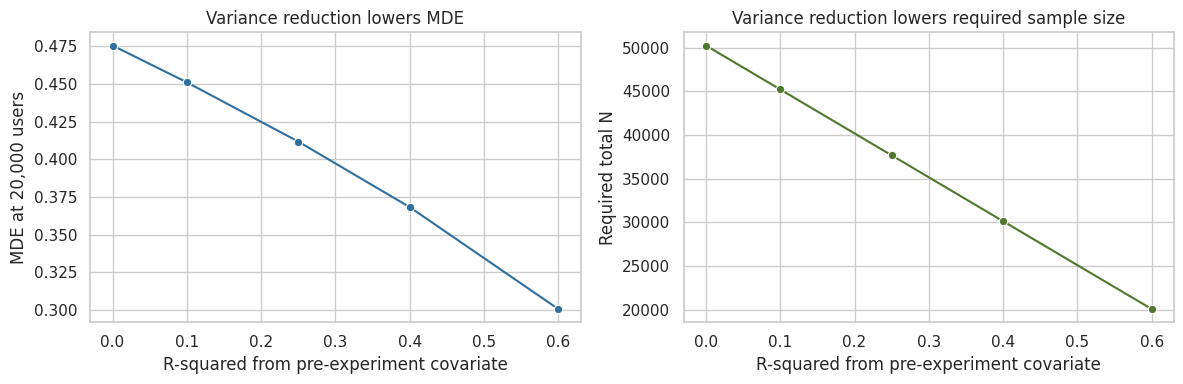

In [18]:
# Build the Variance Reduction and MDE plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=vr_table, x="r_squared_from_pre_covariate", y="mde_at_20k_users", marker="o", color="#2f6f9f", ax=axes[0])
axes[0].set_title("Variance reduction lowers MDE")
axes[0].set_xlabel("R-squared from pre-experiment covariate")
axes[0].set_ylabel("MDE at 20,000 users")

sns.lineplot(data=vr_table, x="r_squared_from_pre_covariate", y="required_n_for_threshold", marker="o", color="#4f772d", ax=axes[1])
axes[1].set_title("Variance reduction lowers required sample size")
axes[1].set_xlabel("R-squared from pre-experiment covariate")
axes[1].set_ylabel("Required total N")

plt.tight_layout()
plt.show()

If pre-experiment data explains 40% of outcome variance, the required sample size falls by roughly 40%. That can turn a four-week experiment into something closer to a two-and-a-half-week experiment, depending on traffic.

The covariate must be measured before treatment assignment or otherwise unaffected by treatment. Post-treatment adjustment can change the causal estimand.

## 12. Allocation Ratio and Cost

Equal allocation is usually most statistically efficient when treatment and control have similar variance and similar cost. But product teams sometimes use unequal allocation:

- small treatment ramps for risk management;
- more control traffic to protect revenue;
- more treatment traffic to collect safety data;
- costly interventions where treatment users are expensive.

For a fixed total sample size, unequal allocation increases the standard error unless there is a cost or variance reason to prefer it.

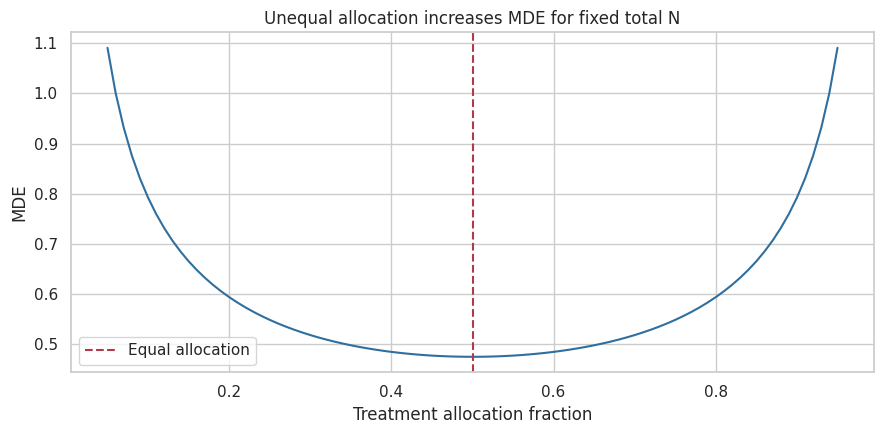

,treatment_fraction,se,mde
0,0.05,0.389,1.091
20,0.25,0.196,0.549
45,0.50,0.170,0.475
70,0.75,0.196,0.549
90,0.95,0.389,1.091


In [19]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
allocation_grid = np.linspace(0.05, 0.95, 91)
allocation_df = pd.DataFrame({
    "treatment_fraction": allocation_grid,
    "se": [se_difference_means(sigma=sigma, n_total=20_000, treatment_fraction=p) for p in allocation_grid],
    "mde": [mde_continuous(sigma=sigma, n_total=20_000, treatment_fraction=p) for p in allocation_grid],
})

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=allocation_df, x="treatment_fraction", y="mde", color="#2f6f9f", ax=ax)
ax.axvline(0.5, color="#b23a48", linestyle="--", label="Equal allocation")
ax.set_title("Unequal allocation increases MDE for fixed total N")
ax.set_xlabel("Treatment allocation fraction")
ax.set_ylabel("MDE")
ax.legend()
plt.tight_layout()
plt.show()

allocation_df.iloc[[0, 20, 45, 70, 90]].round(3)

The curve is minimized near 50/50 allocation. A 10% treatment ramp is much less sensitive than a 50% treatment experiment with the same total number of users.

Ramps often serve as safety tools rather than high-power measurement tools. A ramp can detect large harms, while a full experiment may be needed to measure smaller benefits.

## 13. Duration Planning With Traffic and Eligibility

In product experiments, sample size becomes duration through traffic. But not all traffic is eligible, and not all eligible users trigger the surface.

Suppose the site has 100,000 users per day, but only 12% are eligible for a new onboarding experiment. If the primary estimand is ITT among eligible users, duration is based on eligible users. If the team cares about triggered-user precision, duration depends on trigger rate too.

In [20]:
# Build the summary table used to connect the calculation back to the design question.
daily_users = 100_000
eligibility_rate = 0.12
trigger_rate = 0.35
required_n_itt = sample_size_continuous(sigma=sigma, effect=practical_effect, alpha=0.05, power=0.80)
required_n_triggered = sample_size_continuous(sigma=sigma, effect=practical_effect, alpha=0.05, power=0.80)

traffic_plan = pd.DataFrame({
    "planning_quantity": [
        "Total daily users",
        "Eligibility rate",
        "Eligible users per day",
        "Trigger rate among eligible users",
        "Triggered users per day",
        "Required eligible users for ITT readout",
        "Days for ITT readout",
        "Days for same triggered-user sample size",
    ],
    "value": [
        daily_users,
        eligibility_rate,
        daily_users * eligibility_rate,
        trigger_rate,
        daily_users * eligibility_rate * trigger_rate,
        required_n_itt,
        np.ceil(required_n_itt / (daily_users * eligibility_rate)),
        np.ceil(required_n_triggered / (daily_users * eligibility_rate * trigger_rate)),
    ],
})
traffic_plan.round(2)

,planning_quantity,value
0,Total daily users,100000.00
1,Eligibility rate,0.12
2,Eligible users per day,12000.00
3,Trigger rate among eligible users,0.35
4,Triggered users per day,4200.00
5,Required eligible users for ITT readout,50233.00
6,Days for ITT readout,5.00
7,Days for same triggered-user sample size,12.00


Traffic planning should use the denominator of the estimand. A high-traffic product can still have a slow experiment if the eligible or triggered population is small.

This is common in enterprise products, marketplaces, B2B workflows, medical platforms, and AI systems where only a subset of users encounter a feature in a given time window.

## 14. Planning Table for Multiple Candidate Metrics

Experiment planning often compares several possible primary metrics. A metric closer to business value may be noisier. A metric closer to product behavior may be more sensitive but less directly tied to the decision.

The table below compares candidate metrics by baseline, standard deviation, practical threshold, required sample size, and feasibility.

In [21]:
# Build the summary table used to connect the calculation back to the design question.
metric_plan = pd.DataFrame({
    "metric": ["14-day value", "activation score", "retention indicator", "revenue per user"],
    "metric_type": ["continuous", "continuous", "binary", "continuous"],
    "baseline_mean": [18.0, 4.2, 0.32, 3.5],
    "std_or_rate": [12.0, 2.0, 0.32, 10.5],
    "practical_effect": [0.30, 0.08, 0.008, 0.20],
})

required = []
for row in metric_plan.itertuples(index=False):
    if row.metric_type == "continuous":
        n_req = sample_size_continuous(sigma=row.std_or_rate, effect=row.practical_effect, alpha=0.05, power=0.80)
    else:
        # Search for total N needed for 80% power for a binary metric.
        n_grid_search = np.arange(2_000, 1_000_001, 2_000)
        powers = [analytical_power_proportion(row.std_or_rate, row.practical_effect, n, alpha=0.05) for n in n_grid_search]
        idx = np.argmax(np.array(powers) >= 0.80)
        n_req = n_grid_search[idx] if np.max(powers) >= 0.80 else np.nan
    required.append(n_req)

metric_plan["required_total_n"] = required
metric_plan["required_days_at_12k_eligible_per_day"] = np.ceil(metric_plan["required_total_n"] / 12_000)
metric_plan["relative_effect"] = metric_plan["practical_effect"] / metric_plan["baseline_mean"]
metric_plan.round(3)

,metric,metric_type,baseline_mean,std_or_rate,practical_effect,required_total_n,required_days_at_12k_eligible_per_day,relative_effect
0,14-day value,continuous,18.00,12.00,0.300,50233,5.0,0.017
1,activation score,continuous,4.20,2.00,0.080,19623,2.0,0.019
2,retention indicator,binary,0.32,0.32,0.008,108000,9.0,0.025
3,revenue per user,continuous,3.50,10.50,0.200,86534,8.0,0.057


In Planning Table for Multiple Candidate Metrics, the table turns noise into decision precision. If the detectable effect exceeds the business-relevant effect, the experiment is too weak for that decision.

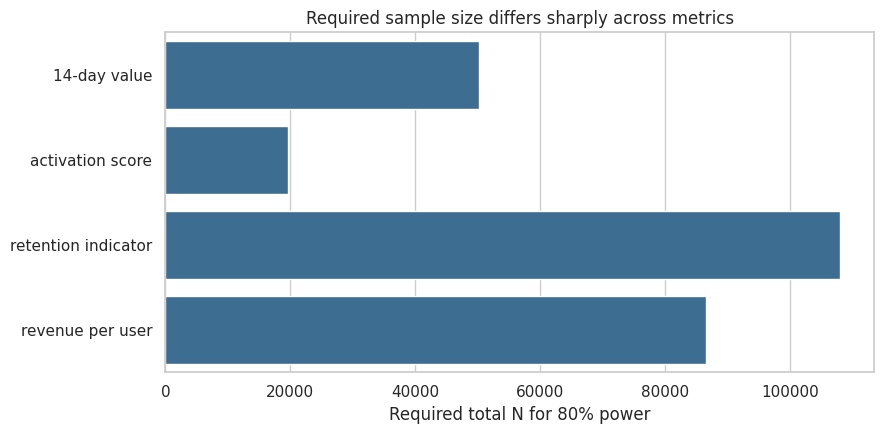

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=metric_plan, y="metric", x="required_total_n", color="#2f6f9f", ax=ax)
ax.set_title("Required sample size differs sharply across metrics")
ax.set_xlabel("Required total N for 80% power")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

The most business-proximal metric is not always the most feasible primary metric. A good planning discussion may choose one primary decision metric, several secondary metrics, and guardrails. The key is to be honest about which metric can support which decision.

This is also why long-term outcomes sometimes require surrogate metrics, holdout designs, or follow-up analyses.

## 15. Experiment Planning Checklist

Before launching an experiment, the team should be able to answer these questions.

| Question | Why it matters |
|---|---|
| What decision will the experiment inform? | Power should target a decision-relevant effect |
| What is the primary metric? | Prevents metric shopping |
| What is the practical effect threshold? | Separates statistical from business significance |
| What is the baseline mean and variance? | Drives MDE and sample size |
| How many eligible units arrive per day? | Converts sample size into duration |
| What is the trigger rate? | Determines precision for triggered analyses |
| What power and alpha are planned? | Defines sensitivity and false-positive tolerance |
| Are there guardrail metrics? | Prevents harmful launches |
| Is the experiment fixed-horizon or sequential? | Avoids invalid peeking |
| Can variance reduction help? | May reduce duration materially |
| What would make the experiment infeasible? | Encourages redesign before wasting traffic |

The practical effect threshold is the most important and often the hardest. It should come from product economics, user value, risk tolerance, or policy relevance, not from what happens to be detectable.

In [23]:
# Build the summary table used to connect the calculation back to the design question.
planning_card = pd.DataFrame({
    "field": [
        "Decision",
        "Primary metric",
        "Smallest practical effect",
        "Baseline SD / rate",
        "Alpha",
        "Power",
        "Required sample size",
        "Eligible traffic per day",
        "Estimated duration",
        "Variance reduction plan",
        "Decision rule",
    ],
    "example": [
        "Launch onboarding checklist to all new accounts?",
        "14-day value per eligible account",
        "0.30 value units",
        "SD = 12.0",
        "0.05 two-sided",
        "0.80",
        f"{required_n:,} eligible accounts",
        "12,000 eligible accounts/day",
        f"{int(np.ceil(required_n / 12_000))} days",
        "Use pre-experiment value if validated before launch",
        "Launch if CI lower bound exceeds 0.30 and guardrails pass",
    ],
})
smart_display(planning_card)

,field,example
0,Decision,Launch onboarding checklist to all new accounts?
1,Primary metric,14-day value per eligible account
2,Smallest practical effect,0.30 value units
3,Baseline SD / rate,SD = 12.0
4,Alpha,0.05 two-sided
5,Power,0.80
6,Required sample size,"50,233 eligible accounts"
7,Eligible traffic per day,"12,000 eligible accounts/day"
8,Estimated duration,5 days
9,Variance reduction plan,Use pre-experiment value if validated before l...


## 16. Key Takeaways

- Power is the probability of detecting a specified effect size, not a generic property of an experiment.
- MDE is the smallest effect a design can detect with a target power and significance threshold.
- MDE decreases with $1/\sqrt{N}$, so detecting effects half as large requires about four times the sample size.
- Practical significance should be defined before the experiment starts.
- Binary and rare-event metrics can require very large samples.
- Underpowered experiments can produce exaggerated significant estimates.
- Variance reduction with pre-treatment covariates can materially reduce MDE and duration.
- Unequal allocation is useful for risk management, but it reduces sensitivity for a fixed total sample size.
- Good planning turns experiments from "let's see what happens" into decision-grade causal evidence.

The next notebook will focus on guardrail metrics and multiple testing: what happens when an experiment has many metrics, many segments, and many opportunities to fool ourselves.

## References

Athey, S., & Imbens, G. W. (2017). The econometrics of randomized experiments. *Handbook of Economic Field Experiments*, 73-140. [https://doi.org/10.1016/bs.hefe.2016.10.003](https://doi.org/10.1016/bs.hefe.2016.10.003)

Cohen, J. (1992). A power primer. *Psychological Bulletin, 112*(1), 155-159. [https://doi.org/10.1037/0033-2909.112.1.155](https://doi.org/10.1037/0033-2909.112.1.155)

Guo, Y., & Deng, A. (2015). Flexible online repeated measures experiment. *arXiv*. [https://doi.org/10.48550/arxiv.1501.00450](https://doi.org/10.48550/arxiv.1501.00450)

Gelman, A., & Carlin, J. B. (2014). Beyond power calculations. *Perspectives on Psychological Science, 9*(6), 641-651. [https://doi.org/10.1177/1745691614551642](https://doi.org/10.1177/1745691614551642)

Hunter, K. B., Miratrix, L., & Porter, K. K. (2024). PUMP: Estimating power, minimum detectable effect size, and sample size when adjusting for multiple outcomes in multi-level experiments. *Journal of Statistical Software, 108*(6). [https://doi.org/10.18637/jss.v108.i06](https://doi.org/10.18637/jss.v108.i06)

Kohavi, R., Longbotham, R., Sommerfield, D., & Henne, R. M. (2009). Controlled experiments on the web: Survey and practical guide. *Data Mining and Knowledge Discovery, 18*(1), 140-181. [https://doi.org/10.1007/s10618-008-0114-1](https://doi.org/10.1007/s10618-008-0114-1)